In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:/Đại học/1. Nghiên cứu Khoa học/Dataset/Folder_Dataset/P2P_Processed.csv")
df

,acc_now_delinq,acc_open_past_24mths,annual_inc,badloan,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earnings,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,0,2,49800.0,0,0,0,0,0,25.120001,995.80,...,False,False,False,False,False,False,False,False,False,False
1,0,3,34000.0,0,0,0,0,0,9.220000,995.80,...,False,False,False,False,False,False,False,False,False,False
2,0,0,34000.0,0,0,0,0,0,25.590000,995.80,...,False,False,False,False,False,False,False,False,False,False
3,0,2,50000.0,1,0,0,0,0,9.310000,750.89,...,False,False,True,False,False,False,False,False,False,False
4,0,2,29000.0,1,0,0,0,0,8.150000,1356.23,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703425,0,0,50000.0,0,0,0,0,0,16.750000,686.90,...,False,False,False,False,False,False,False,False,False,False
2703426,0,3,56000.0,0,0,0,0,0,24.750000,686.90,...,False,False,False,False,True,False,False,False,False,False
2703427,0,4,105000.0,0,0,0,0,0,21.780001,686.90,...,False,False,False,False,False,True,False,False,False,False
2703428,0,4,66560.0,0,0,0,0,0,29.100000,686.90,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.info()

In [3]:
pd.set_option('display.max_rows', None)
df.dtypes

acc_now_delinq                  int64
acc_open_past_24mths            int64
annual_inc                    float64
badloan                         int64
chargeoff_within_12_mths        int64
collections_12_mths_ex_med      int64
delinq_2yrs                     int64
delinq_amnt                     int64
dti                           float64
earnings                      float64
emp_length                    float64
funded_amnt                     int64
grade                           int64
inq_last_12m                  float64
inq_last_6mths                  int64
installment                   float64
int_rate                      float64
loan_amnt                       int64
loan_status                     int64
loan_status_5                   int64
loan_sum                        int64
loan_vol6m                      int64
mort_acc                        int64
mths_since_last_delinq        float64
num_accts_ever_120_pd           int64
num_actv_rev_tl                 int64
num_tl_30dpd

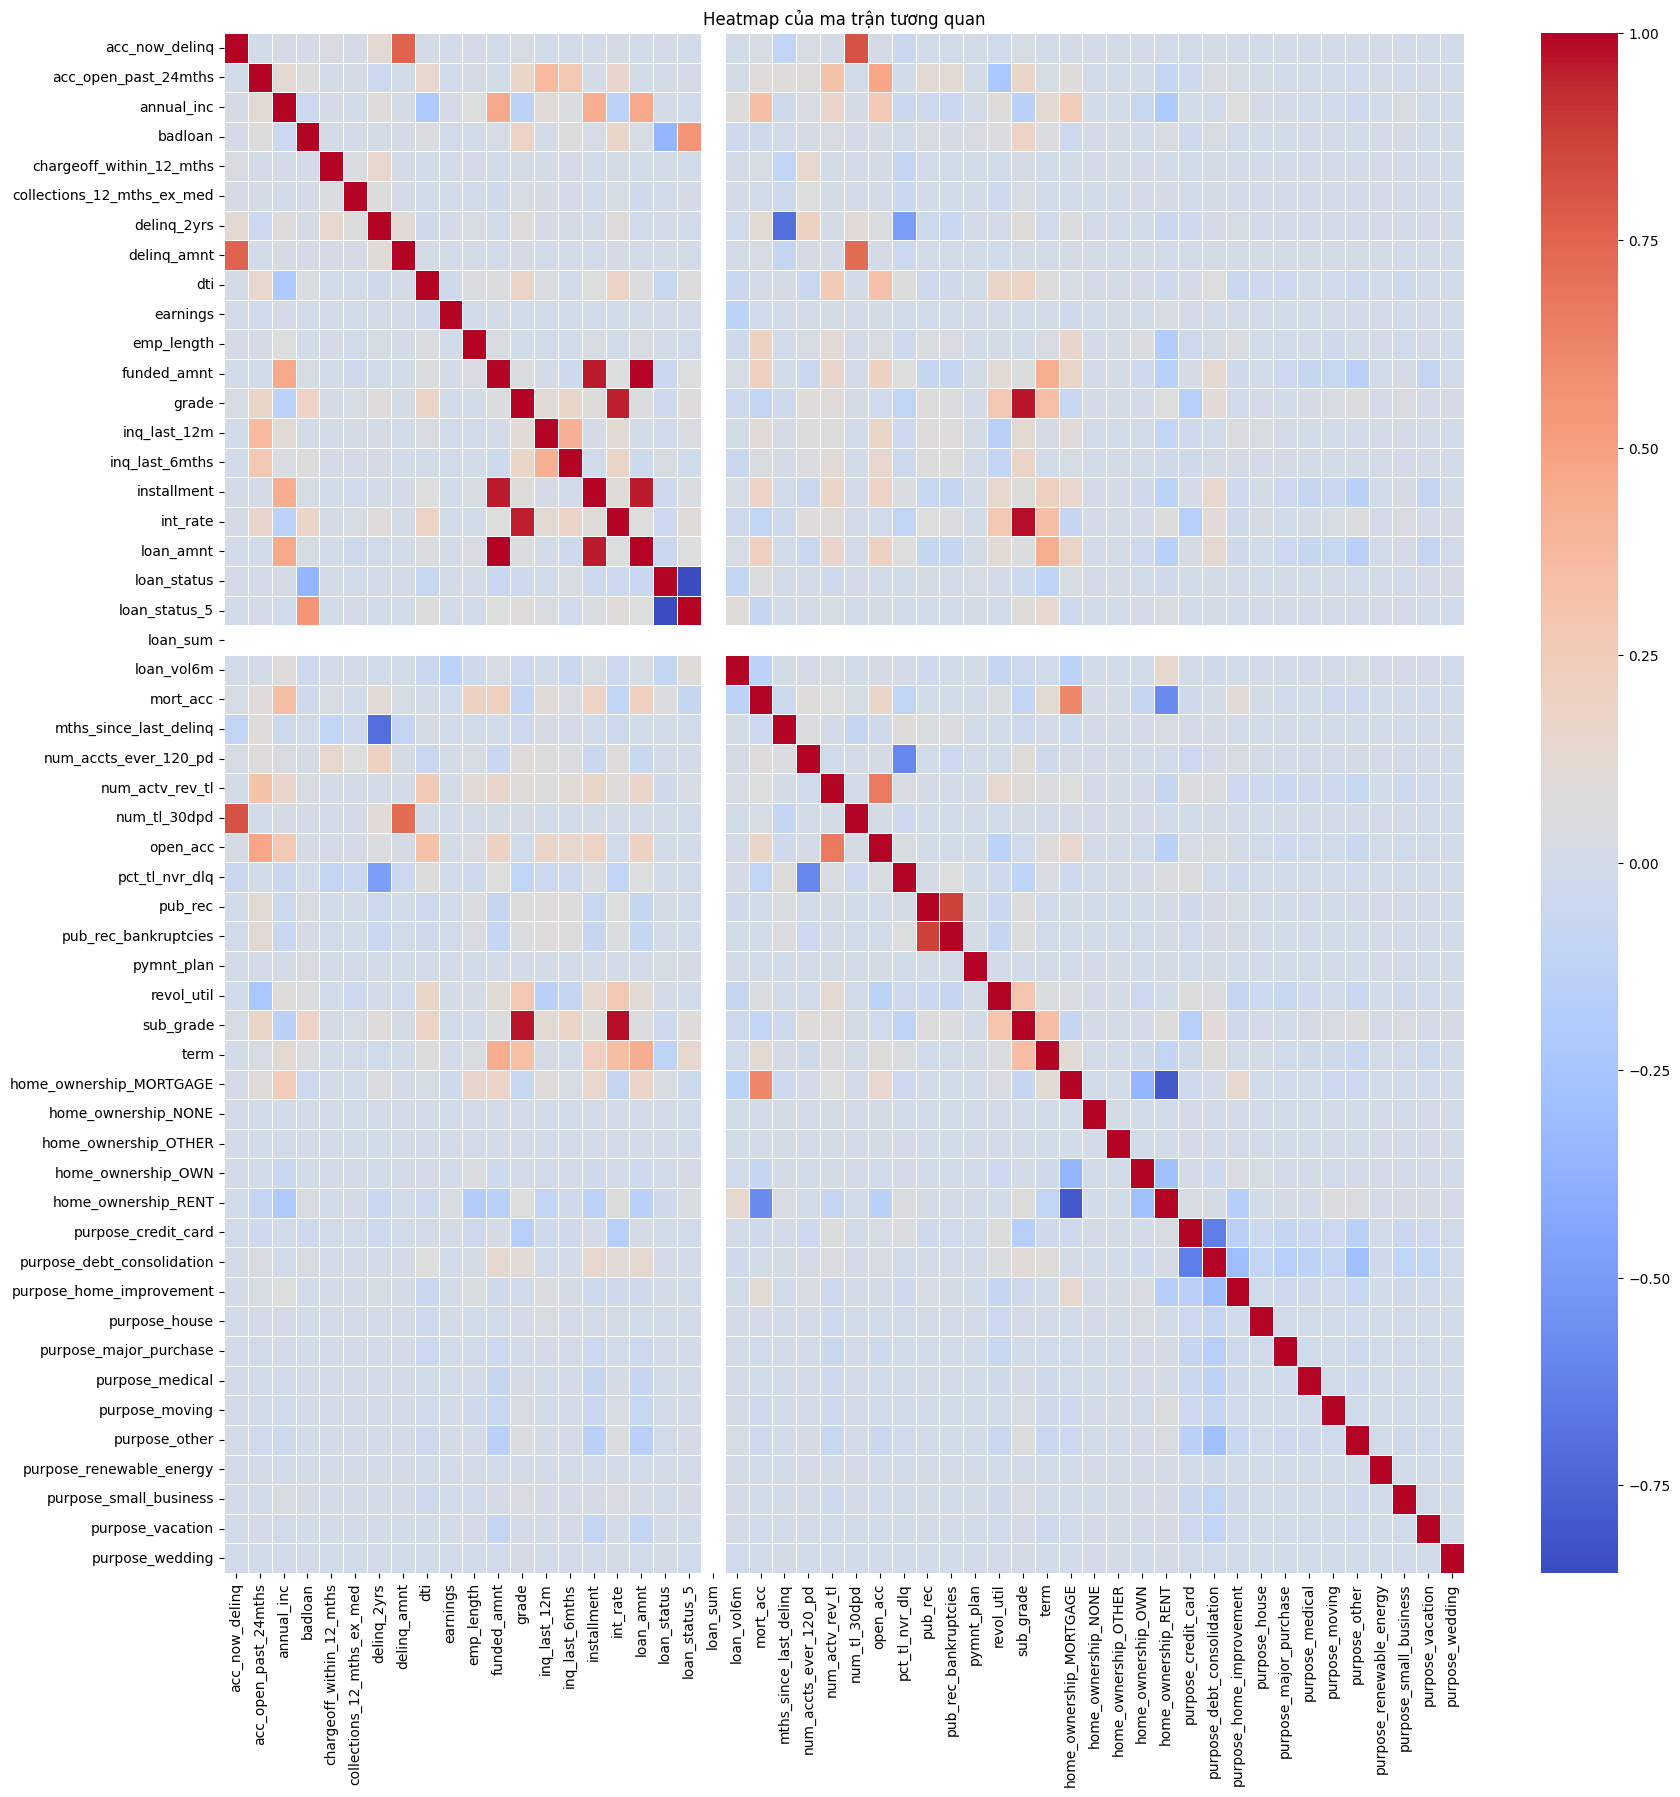

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ Heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(method='spearman'), cmap='coolwarm', linewidths=0.5)

# Hiển thị biểu đồ
plt.title("Heatmap của ma trận tương quan")
plt.show()

# Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [6]:
boolean_cols = df.select_dtypes(include=['bool']).columns
df[boolean_cols] = df[boolean_cols].astype(int)

In [ ]:
X = df.drop(columns=["badloan"])
y = df["badloan"]

# Chuẩn hóa các biến số
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia dữ liệu thành tập train/test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Huấn luyện mô hình hồi quy logistic
model = LogisticRegression()
model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f"🎯 Accuracy: {accuracy:.4f}")
print(f"📊 Confusion Matrix:\n{conf_matrix}")
print(f"🚀 AUC-ROC: {roc_auc:.4f}")

🎯 Accuracy: 1.0000
📊 Confusion Matrix:
[[994936      0]
 [     2  86434]]
🚀 AUC-ROC: 1.0000


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Huấn luyện mô hình
rf_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_rf = rf_model.predict(X_test)

# Đánh giá mô hình
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"🎯 RF Accuracy: {accuracy_rf:.4f}")
print(f"📊 RF Confusion Matrix:\n{conf_matrix_rf}")
print(f"🚀 RF AUC-ROC: {roc_auc_rf:.4f}")


🎯 RF Accuracy: 1.0000
📊 RF Confusion Matrix:
[[994936      0]
 [     0  86436]]
🚀 RF AUC-ROC: 1.0000


# XG Boost

In [ ]:
from xgboost import XGBClassifier

# Khởi tạo mô hình XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric="logloss")

# Huấn luyện mô hình
xgb_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_xgb = xgb_model.predict(X_test)

# Đánh giá mô hình
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print(f"🎯 XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"📊 XGBoost Confusion Matrix:\n{conf_matrix_xgb}")
print(f"🚀 XGBoost AUC-ROC: {roc_auc_xgb:.4f}")

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:02:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🎯 XGBoost Accuracy: 1.0000
📊 XGBoost Confusion Matrix:
[[994936      0]
 [     0  86436]]
🚀 XGBoost AUC-ROC: 1.0000
